# TP1 Statistical learning with extreme values: homework
By: Adonis JAMAL

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(123)
plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.grid"] = True

In [2]:
# Import datasets
port = pd.read_csv("portpirie_yearly_maxima.csv",index_col=0);
rain = pd.read_csv("daily_rainfall_data.csv",index_col=0);

## 2C. GPD fit and diagnostics

We recall that we denote $X$ the random variable having same law as the supposedly i.i.d. random variables $(X_{i})_{i=1...}$ denoting the random recorded daily rain intensities.

**1.** Fix $u=30$ mm as the threshold. Fit a GPD on the exceedances $X-u$.

In [3]:
rainfall_data = rain["daily_rainfall"]

# Fix u = 30 mm
u = 30

excesses = rainfall_data[rainfall_data > u] - u

# Fit GPD to excesses
c, loc, scale = stats.genpareto.fit(excesses, floc=0.0)

print("Fitted GPD parameters for excesses over u = 30 mm:")
print(f"Shape γ: {c}")
print(f"Location μ: {loc}")
print(f"Scale σ: {scale}")

Fitted GPD parameters for excesses over u = 30 mm:
Shape γ: 0.18449634026530343
Location μ: 0.0
Scale σ: 7.440247760341805


**2.** Display the GPD QQ-plot and comment on the fit.

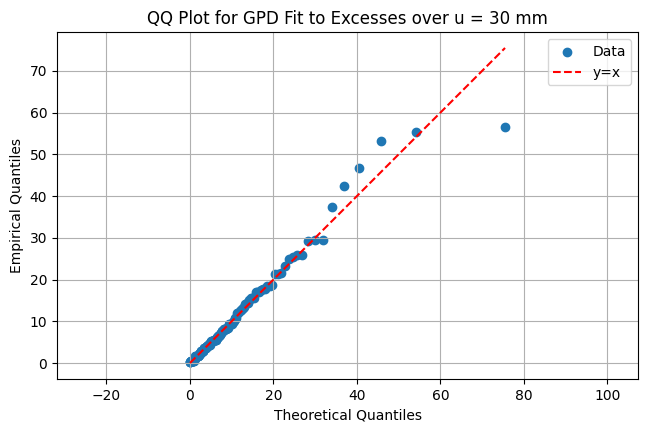

In [4]:
n = len(excesses)
pos = (np.arange(n) + 0.5) / n
empirical_quantiles = np.sort(excesses)

fitted_gpd = stats.genpareto(c=c, loc=loc, scale=scale)
theoretical_quantiles = fitted_gpd.ppf(pos)

# QQ plot
plt.figure()
plt.scatter(theoretical_quantiles, empirical_quantiles, label='Data')

min_val = min(np.min(theoretical_quantiles), np.min(empirical_quantiles))
max_val = max(np.max(theoretical_quantiles), np.max(empirical_quantiles))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')

plt.title('QQ Plot for GPD Fit to Excesses over u = 30 mm')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Empirical Quantiles')
plt.legend()
plt.axis('equal')
plt.show()

The points in QQ-plot should be close to the diagonal line if the GPD is a good fit for the exceedances. Deviations from this line, especially in the tails, indicate that the GPD may not adequately capture the behavior of extreme values.

In our case, for the highest quantities, the empirical quantiles are above the theoretical quantiles, indicating that the model might be slightly underestimating the most extreme rainfall events.

While the GPD model might a good fit for most of the exceedances over the threshold, the fit in the extreme upper tail is not perfect.

**3.** Let's denote Y a random variable having a $GPD(\gamma,\beta)$ distribution, i.e. $\forall y>0$, 
$$P(Y>y)= \left(1+\gamma\frac{y}{\beta}\right)_{+}^{-\frac{1}{\gamma}}$$
with $\gamma \ne 0$.

**(a)** Let's have T a duration. Let's have the associated quantile $z_{T}$ such that $P(Y>z_{T})= 1/T$. Give a close form expression of $z_{T}$.

Let's start with:
$$ \left(1 + \gamma \frac{z_T}{\beta}\right)^{-\frac{1}{\gamma}} = \frac{1}{T} $$

We want to isolate the term $z_T$. By raising both sides to the power of $-\gamma$, we get:
$$ 1 + \gamma \frac{z_T}{\beta} = T^\gamma $$

By isolating $z_T$, we get the following closed-form expression:
$$ z_T = \frac{\beta}{\gamma} (T^\gamma - 1) $$

**(b)** Define the waiting time to the first exceedance of $z_T$: $\tau_{z_{T}}=min\{t\ge1:X_{t}>z_{T}\}$. What is the distribution of $\tau_{z_T}$?

Since our problem uses an excess variable $Y = X - u$, we will calculate the probability that a given $X_t$ exceeds $u + z_T$:

$
\begin{aligned}
    \mathbb{P}(X_t > u + z_T) 
    &= \mathbb{P}(X_t > u) \mathbb{P}(X_t > u + z_T | X_t > u)\\
    &= \mathbb{P}(X_t > u) \mathbb{P}(Y > z_T)\\
    &= \mathbb{P}(X_t > u) \times \frac{1}{T}
\end{aligned}
$

The waiting time to the first exceedance of $z_T$, $\tau_{z_T}$, represents the number of trials needed to get the first successs, where a success is defined as $X_t > u + z_T$. 

Since each trial is independent and has the same probability of success, $\tau_{z_T}$ follows a geometric distribution with parameter $p = \mathbb{P}(X_t > u) \times \frac{1}{T}$.

**(c)** Give the value of $\mathbb{E}[\tau_{z_{T}}]$. According to you why is $z_{T}$ called the return level associated with the period T?

Since $\tau_{z_T}$ follows a geometric distribution with probability $p = \frac{\mathbb{P}(X > u)}{T}$, we have:
$$ \mathbb{E}[\tau_{z_T}] = \frac{T}{\mathbb{P}(X > u)} $$

This value represents the average number of days we would have to wait to observe a rainfall intensity greater than $u + z_T$.

In our case, we can expect to see an excess greater than $z_T$ once for every $T$ times the threshold $u$ is crossed. 

The total rainfall will then exceed $u + z_T$ on average once every $\frac{T}{\mathbb{P}(X > u)}$ days. This is why $z_T$ is called the (excess) return level associated with the period $T$.

**(d)** Compute the 100-years return level of rain intensity. Caution: Don't forget to consider the probability of X being higher than the threshold u.

In [5]:
return_period_years = 100
return_period_days = return_period_years * 365.25

total_observations = len(rainfall_data)
n_exceedances = len(excesses)

# Empirical probability of exceeding the threshold u
p_exceed_u = n_exceedances / total_observations

# Return period T
T = return_period_days * p_exceed_u

print(f"Total number of observations: {total_observations}")
print(f"Number of exceedances over u={u} mm: {n_exceedances}")
print(f"Empirical probability of exceedance: {p_exceed_u:.6f}")
print(f"Return period T: {T:.2f}")

# Calculate the return level z_T
gamma, beta = c, scale
z_T = (beta / gamma) * (T**gamma - 1)

print(f"Fitted GPD parameters: γ={gamma:.4f}, σ={beta:.4f}")
print(f"Excess return level for T={T:.2f} (z_T): {z_T:.2f} mm")

# 100-year return level
return_level_100y = u + z_T

print(f"The 100-year return level for daily rainfall intensity is: {return_level_100y:.2f} mm")

Total number of observations: 17531
Number of exceedances over u=30 mm: 152
Empirical probability of exceedance: 0.008670
Return period T: 316.68
Fitted GPD parameters: γ=0.1845, σ=7.4402
Excess return level for T=316.68 (z_T): 76.34 mm
The 100-year return level for daily rainfall intensity is: 106.34 mm


## 2D. Compute return level with block maxima method

**1.** Suggest another way to estimate the 100-years return level of rain intensity, but using the Block Maxima method. Provide a structured and detailed answer. In particular you will comment on your block size choice advantages and drawbacks. You will make the parallel between this hyperparameter and another choice we had to do in the GPD approach.

Instead of using the Peak-Over-Threshold (POT) approach, which uses the GPD, we use the Block Maxima method (BMM).\
This approach is founded on the Fisher-Tippet-Gnedenko theorem, which states that a max-stable distribution converges to one of three types of distributions: Gumbel, Fréchet or Weibull. The three distributions fall into the same family, the Generalized Extreme Value (GEV) distribution.


The BMM procedure is:
1. Divide the data into non-overlapping blocks of equal size.
2. Extract the maxima within each block.
3. Fit a GEV distrubtion to the new dataset of block maxima. We will get three parameters: the location μ, the scale σ and the shape γ.
4. We calculate the N-year return level using the fitted GEV distribution.


For the choice of block size, in particular in the context of rainfall data, we can use one year as the block size. The data will be grouped by year and we will find the maximum rainfall for each year.\
The advantage of such a block size is that it aligns with the annual cycles of weather patterns and handles seasonality (dry and rainy seasons), capturing the true annual extreme. Having a yearly block size also allows for interpretable return periods.\
The drawbacks of a yearly block size include the potential waste of data. For example, the second-highest rainfall in one year could be much larger than the maximum in another year, but we discard this information. A second drawback is the fact that the number of maxima is determined by the number of years in the dataset. If the dataset covers a short period, we may have too few maxima to reliably estimate the GEV parameters, leading to high variance in the estimates.


Parallel between BMM and POT:\
The hyperparameter for BMM is the block size, whereas in POT we set a threshold $u$.\
For large block sizes, the bias is low as the maxima are more likely to be truly extreme, so the GEV limit theorem is a good approximation. The variance however is high as we have few data points (one per block), and thus greater uncertainty in the parameter estimates.\
We also find low bias and high variance for a high threshold $u$. The GPD approximation for the tail is more accurate, and leads to lower bias. However, with fewer exceedances, we have greater uncertainty in the parameter estimates (high variance).

On the other hand, for small block sizes, the bias is high since the maxima of smaller blocks may not be extreme enough for the GEV theorem. The variance however is low since we have more data points.\
The same goes for a low threshold $u$. We have high bias as we include data that may not belong to the tail of the distribution, violating the GPD model's assumption. The variance however is low as we have more exceedances.


**2.** Compare this estimation with the one obtained with the GPD approach.

In [6]:
# Block maxima approach
# Define block size
block_size = 365
total_observations = len(rainfall_data)

block_ids = np.arange(total_observations) // block_size

# Block maxima
block_maxima = rainfall_data.groupby(block_ids).max()

# Fit GEV to block maxima
c_gev, mu_gev, sigma_gev = stats.genextreme.fit(block_maxima)
gamma_gev = -c_gev

print("Fitted GEV parameters for annual maxima:")
print(f"Shape γ: {gamma_gev}")
print(f"Location μ: {mu_gev}")
print(f"Scale σ: {sigma_gev}")

# 100-year return level using GEV
N = 100
p = 1 - 1/N
return_level_gev = stats.genextreme.ppf(p, c=c_gev, loc=mu_gev, scale=sigma_gev)

print(f"The 100-year return level is: {return_level_gev:.2f} mm")

Fitted GEV parameters for annual maxima:
Shape γ: -0.1597923804631626
Location μ: 40.67190515279461
Scale σ: 14.193579447661616
The 100-year return level is: 86.91 mm


The 100-year return level estimated using the GPD method is 106.34 mm, while the estimate using the GEV method is 86.91 mm.

The GPD estimate is significantly higher than the GEV estimate. This difference could be due to:
1. The fact that GPD uses more tail data.\
Since we consider all data points above the set threshold, we may capture more extreme events, leading to a higher return level estimate. However, if the threshold is too high, we may have only the most extreme events, which can lead to overestimation and higher return levels.
2. The GEV method uses only the maximum value from each block (year).\
Since the block size is one year, we may miss some extreme events that occur within the year but are not the maximum. This can lead to underestimation of the return level.
3. The data plays an important role.\
If we have many extreme events in a single season or year, the GPD method will capture these, while the GEV method will only consider the maximum for that year.

# Part 3
## Minima (Glass Fiber) GEV on lower tail

**Context.** We now study extreme minima using experimental data on glass-fiber breaking strengths. The experiment consists of subjecting short glass fibers (each of length 1.5 cm) to mechanical vibrations whose power is gradually increased. The vibration intensity, controlled through both frequency and amplitude, is raised until each fiber sample breaks. The corresponding breaking power is then recorded as a measure of its strength.

To interpret these data, we use a simple conceptual model. We consider each 1.5 cm glass fiber sample as a small system composed of M microscopic glass sub-fibers. Each sub-fiber has its own intrinsic resistance (or breaking power), and the entire system fails as soon as the weakest sub-fiber breaks. In this framework, the observed breaking strength $X_{i}$ of sample i corresponds to the minimum among the M sub-fiber strengths:
$$X_{i}=min(X_{i,1},X_{i,2},...,X_{i,M})$$
where the $X_{i,j}$ are assumed to be i.i.d. random variables representing the strength of individual sub-fibers.

Hence, the recorded dataset can be viewed as a collection of such minima:
$X_{1},X_{2},...,X_{n}$
each corresponding to one experimental trial (one fiber system). This setup naturally leads us to study the statistical behavior of extreme minima. For convenience, we will also consider the transformation $Y=-X$, so that the minima of X become maxima of Y; this allows us to reuse standard Generalized Extreme Value (GEV) tools developed for maxima.

### 3A. Data reading and exploration

**1.** Load the CSV `glassfiber.csv` (single column: `strength`). Let X denote the breaking strength. The dataset contains 63 observations corresponding to the breaking strengths of glass fibers under controlled experimental conditions, interpreted as the minimum resistance among the sub-fibers composing each system.

In [7]:
glassfiber = pd.read_csv("glassfiber.csv")
X = glassfiber["strength"]
print(f"Number of observations: {len(X)}")

Number of observations: 63


**2.** Plot a histogram of X and report min X, median(X), and max X.

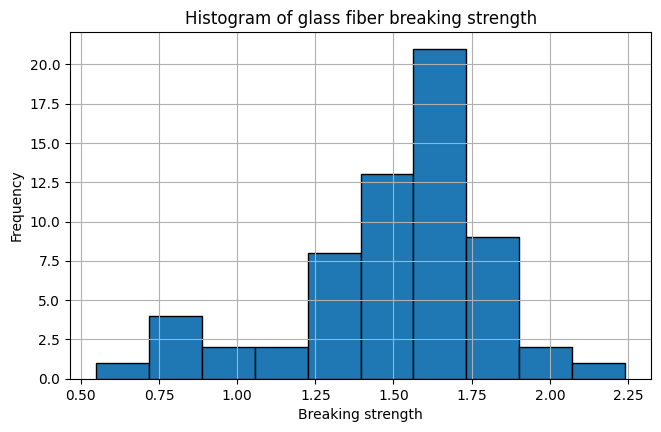

Minimum breaking strength: 0.55
Median breaking strenght: 1.59
Maximum breaking strength: 2.24


In [8]:
plt.figure()
plt.hist(X, bins=10, edgecolor="black")
plt.title("Histogram of glass fiber breaking strength")
plt.xlabel("Breaking strength")
plt.ylabel("Frequency")
plt.show()

min_X = X.min()
median_X = X.median()
max_X = X.max()

print(f"Minimum breaking strength: {min_X}")
print(f"Median breaking strenght: {median_X}")
print(f"Maximum breaking strength: {max_X}")

**3.** Comment on the left tail: Give a simple physical intuition for the existence or not of a left bound.

For any material, the breaking strength must be positive. A breaking strength of zero or a negative value is physically impossible. This physical constraint implies that for any material, in our case glass fibers, the distribution of breaking strengths must have a natural lower bound (left bound) greater than zero for the breaking strength.

Moreover, the breaking strength of the glass fiber is determined by its weakest sub-fiber. This doesn't create a bound, but rather means that our dataset is a collection of minimums, which skews the distribution to the left and causes the observed strengths to cluster towards the physical lower bound.

### 3B. GEV fit for minima via sign flip

**1.** Define $Y=-X$ and fit a GEV to Y with `scipy.stats.genextreme.fit` (recall SciPy uses $c=-\xi$).

In [9]:
Y = -X

c_gev, mu_gev, sigma_gev = stats.genextreme.fit(Y)
xi_gev = -c_gev

print("GEV fit parameters for Y = -X:")
print(f"Shape ξ: {xi_gev:.4f}")
print(f"Location μ: {mu_gev:.4f}")
print(f"Scale σ: {sigma_gev:.4f}")

GEV fit parameters for Y = -X:
Shape ξ: -0.0843
Location μ: -1.6416
Scale σ: 0.2729


**2.** Report $(\hat{\mu}_{Y},\hat{\sigma}_{Y},\hat{\xi}_{Y})$ and interpret the sign of $\hat{\xi}_{Y}$. Translate this to the lower tail of X: does it suggest a bounded lower endpoint (Weibull-type), light tail (Gumbel), or heavy tail (Fréchet)? Could you have guessed this tail shape earlier?

The shape parameter $\hat{\xi_Y}$ is negative and close to $0$. For a GEV distribution of maxima, a negative shape parameter corresponds to the Weibull family, signifying that the distribution of Y has a finite upper bound.

Since $Y = -X$, this implies that a finite upper bound for $Y$ is a finite lower bound for $X$. Therefore, the distribution of $X$ also belongs to the Weibull family, indicating a bounded lower endpoint.

This result confirms our physical intuition in section 3A regarding the left tail. We could have guessed this tail shape earlier, as it aligns with the fact that a physical property such as breaking strength cannot be zero or negative, implying the existence of bounded lower endpoint (Weibull-type).

### 3C. Diagnostics for minima

**1.** QQ-plot (GEV): Show empirical quantiles of Y vs theoretical quantiles of the fitted GEV. Focus your comments on the points corresponding to small X (i.e., large Y).

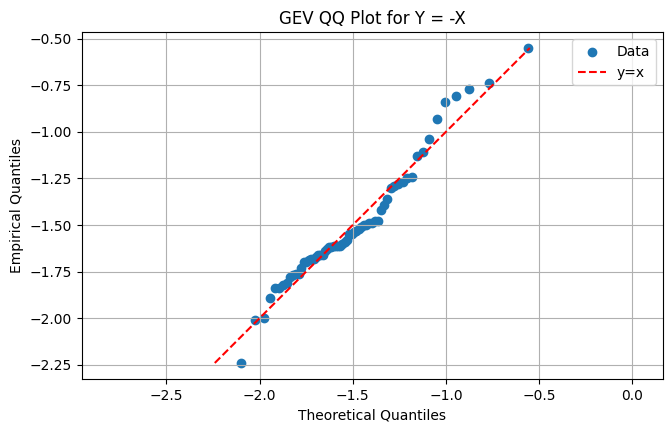

In [10]:
n = len(Y)
empirical_probabilities = (np.arange(1, n + 1) - 0.5) / n
empirical_quantiles = np.sort(Y)

theoretical_quantiles = stats.genextreme.ppf(empirical_probabilities, c=c_gev, loc=mu_gev, scale=sigma_gev)

# QQ plot
plt.figure()
plt.scatter(theoretical_quantiles, empirical_quantiles, label='Data')

min_val = min(np.min(theoretical_quantiles), np.min(empirical_quantiles))
max_val = max(np.max(theoretical_quantiles), np.max(empirical_quantiles))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')

plt.title('GEV QQ Plot for Y = -X')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Empirical Quantiles')
plt.legend()
plt.axis('equal')
plt.show()

The QQ plot shows that the empirical quantiles of Y align generally well with the theoretical quantiles from the fitted GEV distribution, indicating that the GEV model provides a good fit for most of the data.

However, deviations are observed for small theoretical quantiles, which correspond to large values of Y and thus small values of X. This indicates that the GEV model may not perfectly capture the behavior of the extreme lower tail of the breaking strength distribution.

The points lie above the diagonal line for these small theoritical quantiles, suggesting that the GEV model is underestimating the extreme minima (smallest breaking strengths). This could be due to the limited number of extreme minima in the dataset, leading to greater uncertainty in the tail fit.

**2.** "Return levels" for minima: Can you give an expression of the quantile of Y with respect to a quantile level assuming the GEV modeling is relevant? Using this expression and the fitted model on Y, compute low quantiles for X:
$$q_{p}^{(X)}=-Q_{1-p}^{(Y)}$$
for $p\in\{0.01,0.005,0.001\}$ where $Q_{q}^{(Y)}$ is the q-quantile under the fitted GEV for Y.

Assuming the GEV modeling is relevant, the cumulative distribution function for a GEV distribution is given by:
$$ F(y; \mu, \sigma, \xi) = \exp\left(-\left[1 + \xi \frac{y - \mu}{\sigma}\right]^{-1/\xi}\right) $$

To find the q-quantile $Q_q$, we set $F(Q_q) = q$ and solve for $Q_q$:
\begin{aligned}
    q &= \exp\left(-\left[1 + \xi \frac{Q_q - \mu}{\sigma}\right]^{-1/\xi}\right)\\
    \log(q) &= -\left[1 + \xi \frac{Q_q - \mu}{\sigma}\right]^{-1/\xi}\\
    \left(-\log(q)\right)^{-\xi} &= 1 + \xi \frac{Q_q - \mu}{\sigma} \\
    Q_q &= \mu + \frac{\sigma}{\xi} \left(\left(-\log(q)\right)^{-\xi} - 1\right)
\end{aligned}

This is the expression for the q-quantile $Q_q$ of the fitted GEV model for Y.

In [11]:
p_values = [0.01, 0.005, 0.001]

for p in p_values:
    q = 1 - p
    
    Q_y = mu_gev + (sigma_gev / xi_gev) * ((-np.log(q))**(-xi_gev) - 1)
    Q_x = -Q_y

    print(f"p = {p:<5} | q = 1 - p = {q:<5} | Low quantile Q_x = {Q_x:.4f}")

p = 0.01  | q = 1 - p = 0.99  | Low quantile Q_x = 0.6012
p = 0.005 | q = 1 - p = 0.995 | Low quantile Q_x = 0.4761
p = 0.001 | q = 1 - p = 0.999 | Low quantile Q_x = 0.2131


### 3D. Model selection

**Context.** In the previous section, we fitted a Generalized Extreme Value (GEV) distribution to the transformed variable $Y=-X$, obtaining parameter estimates $\hat{\mu}_{Y}, \hat{\sigma}_{Y}, \hat{\xi}_{Y}$. You found that the estimated shape parameter $\hat{\xi}_{Y}$ was close to zero. Since the case $\xi=0$ corresponds to the Gumbel distribution, it is natural to ask whether the additional parameter $\xi$ is truly needed.

Compare the restricted Gumbel model $(\xi=0)$ to the full GEV model ($\xi$ free) using a Likelihood Ratio Test (LRT). Provide a structured answer in which you will explain each step and provide intermediate conclusions.

**Reminder: Likelihood Ratio Test**

Let us consider two nested statistical models: $\mathcal{M}_{0}\subset\mathcal{M}_{1}$, where the parameter vector in the full model can be written as $\theta=(\theta_{0},\theta_{1})$, with $\theta_{0}\in\Theta_{0}\subset\mathbb{R}^{p_{0}}$ and $\theta_{1}\in\Theta_{1}\subset\mathbb{R}^{p_{1}}$. The two models are then written as:
$$ \mathcal{M}_{1}=\{P_{\theta_{0},\theta_{1}}:(\theta_{0},\theta_{1})\in\Theta_{0}\times\Theta_{1}\} $$
$$ \mathcal{M}_{0}=\{P_{\theta_{0},0}:\theta_{0}\in\Theta_{0}\}\subset\mathcal{M}_{1} $$
That is, the restricted model $\mathcal{M}_{0}$ fixes the sub-parameter $\theta_{1}=0$, while the full model $\mathcal{M}_{1}$ allows it to vary freely.

**Hypothesis to be tested:**
$H_{0}:\theta_{1}=0$ (restricted model $\mathcal{M}_{0}$) VS. $H_{1}:\theta_{1}\in\Theta_{1}$ (full model $\mathcal{M}_{1}$).

Then under $H_{0}$ and suitable regularity conditions (we will suppose those conditions are met):
$$ T:=2 \ln\left(\frac{\sup_{\theta\in\mathcal{M}_{1}}\mathcal{L}(\theta|x_{n})}{\sup_{\theta\in\mathcal{M}_{0}}\mathcal{L}(\theta|x_{n})}\right) \xrightarrow[n\to\infty]{d} \chi_{p_{1}}^{2} $$
Thus, the likelihood ratio test relies on:
1. Compute the T statistics with the fitted parameters for each of the models
2. Check if it is over a given quantile of $\chi_{p_{1}}^{2}$
3. Reject $H_{0}$ with a given risk (the one associated with the quantile chosen earlier)

First note that the full model $\mathcal{M}_1$ is the GEV distribution with parameters $(\mu, \sigma, \xi)$, while the restricted model $\mathcal{M}_0$ is the Gumbel distribution with parameters $(\mu, \sigma)$ and $\xi = 0$. 

The null hypothesis $H_0$ is that the shape parameter $\xi$ is equal to zero (Gumbel distribution), while the alternative hypothesis $H_1$ is that $\xi$ can take any value (GEV distribution).

We start by fitting both models to the data Y and obtaining the maximum likelihood estimates of their parameters.

In [12]:
log_likelihood_gev = np.sum(stats.genextreme.logpdf(Y, c=c_gev, loc=mu_gev, scale=sigma_gev))

# Restricted Gumbel model (ξ = 0)
mu_gumbel, sigma_gumbel = stats.gumbel_r.fit(Y)

# Log-likelihood for the restricted Gumbel model
log_likelihood_gumbel = np.sum(stats.gumbel_r.logpdf(Y, loc=mu_gumbel, scale=sigma_gumbel))
print(f"Maximized log-likelihood of the GEV fit: {log_likelihood_gev:.4f}")
print(f"Maximized log-likelihood of the restricted Gumbel fit: {log_likelihood_gumbel:.4f}")

Maximized log-likelihood of the GEV fit: -14.2853
Maximized log-likelihood of the restricted Gumbel fit: -14.9561


We then compute the likelihood ratio test statistic T:

In [13]:
# T statistics with the fitted parameters for each of the models
T = 2 * (log_likelihood_gev - log_likelihood_gumbel)
print(f"Likelihood ratio test statistic T: {T:.4f}")

Likelihood ratio test statistic T: 1.3415


Finally, we compare to the chi-squared distribution with one degree of freedom (since the full model has one additional parameter, $\xi$) to obtain the p-value.

In [14]:
# Degrees of freedom
df = 1

# P-value calculation
p_value = 1 - stats.chi2.cdf(T, df)
print(f"Degrees of freedom: {df}")
print(f"p-value for the likelihood ratio test: {p_value:.4f}")

Degrees of freedom: 1
p-value for the likelihood ratio test: 0.2468


The calculated p-value for the likelihood ratio test is 0.2468, which is greater than common significance levels such as 0.05 or 0.01. Therefore, we fail to reject the null hypothesis $H_0$ that the shape parameter $\xi$ is equal to zero.

Based on the Likelihood Ratio Test, there is insufficient evidence to suggest that the shape parameter $\xi$ significantly differs from zero. This implies that the simpler Gumbel model (with $\xi = 0$) is adequate for modeling the extreme minima of the glass fiber breaking strengths. Thus, we can conclude that the additional complexity of estimating a non-zero shape parameter is not justified by the data.